In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [13]:
# 2. MNIST 데이터셋 불러오기

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [14]:
# 3. 데이터 전처리

# x_train.shape,y_train.shape
x_train = x_train / 255.0 # 픽셀값이 0~255이기 때문에 0~1 범위로 정규화 수행
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1) # CNN 입력을 받기위해서 batch, height, width, channel 형태로 변환
x_test = x_test.reshape(-1, 28, 28, 1)

In [18]:
model = models.Sequential([
    # 첫번째 합성곱 레이어
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)), # 특징 맵을 2x2로 축소하여 계산량 감소, 실제 중요한 특징만 다시 뽑음

    # 두번째 레이어 
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.3),

    # Fully Connected Layer
    layers.Flatten(),     # CNN의 2D 출력을 1D 벡터로 변환
    layers.Dense(128, activation='relu'), # 128개의 뉴런으로 특징에 대해 학습
    layers.Dropout(0.5),    # DropOut 적용

    layers.Dense(10, activation='softmax') # softmax는 10개의 클래스 각각의 확률값을 출력하고, 그 중 가장 높은 값으로 예측값으로 치환

])

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    x_train,y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9079 - loss: 0.2939 - val_accuracy: 0.9822 - val_loss: 0.0639
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9690 - loss: 0.1040 - val_accuracy: 0.9860 - val_loss: 0.0471
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9765 - loss: 0.0770 - val_accuracy: 0.9876 - val_loss: 0.0406
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9799 - loss: 0.0663 - val_accuracy: 0.9880 - val_loss: 0.0412
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9828 - loss: 0.0553 - val_accuracy: 0.9876 - val_loss: 0.0416


In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"MNIST 테스트 정확도: {test_acc:.4f}")
print(f"MNISH 테스트 손실값: {test_loss:.4f}")

MNIST 테스트 정확도: 0.9896
MNISH 테스트 손실값: 0.0303


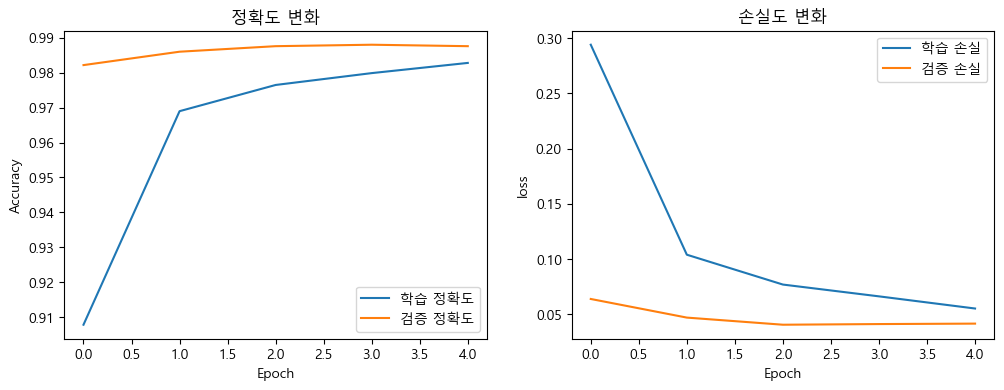

In [25]:
plt.figure(figsize=(12,4))

# 정확도 그래프
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='학습 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title("정확도 변화")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
 
# 손실 그래프
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='학습 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title("손실도 변화")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [26]:
# 예측 수행

predictions = model.predict(x_test)             # 테스트 데이터 전체에 대한 예측 결과(확률값) 생성
pred_labels = np.argmax(predictions, axis=1)    
# 클래스 확률값 중에서 가장 높은 확률을 가진 클래스를 선택 (가장 높은 확률 클래스 1치환, 나머지는 0으로 치환)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


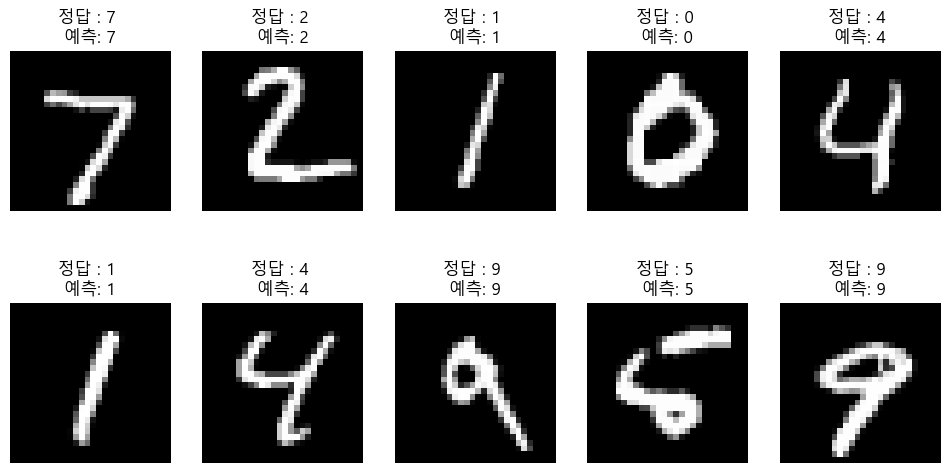

In [33]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"정답 : {y_test[i]} \n예측: {pred_labels[i]}")
    plt.axis("off")
    #plt.suptitle("MNIST 이미지 예측 결과", fontsize=16)
    
plt.show()

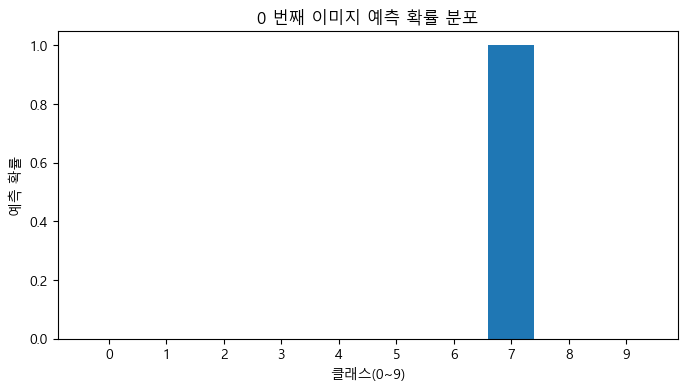

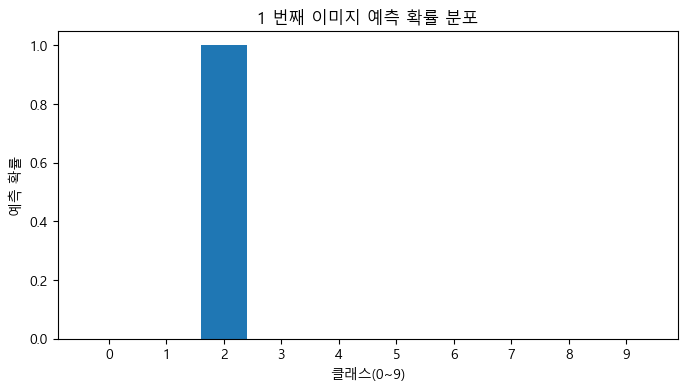

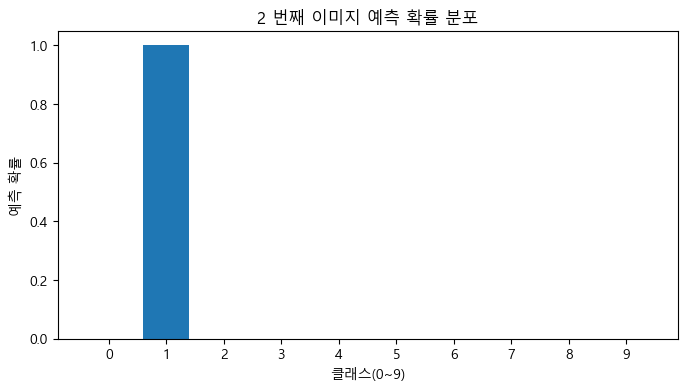

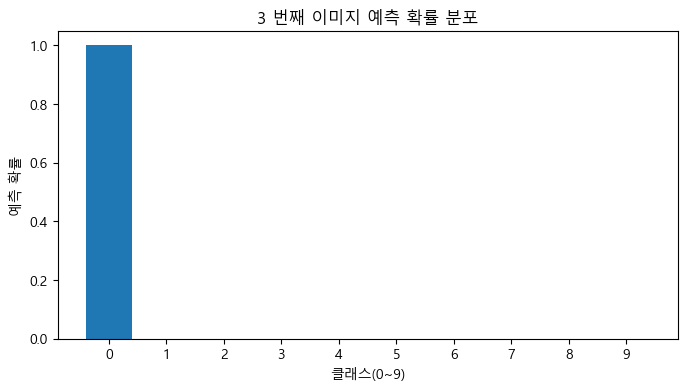

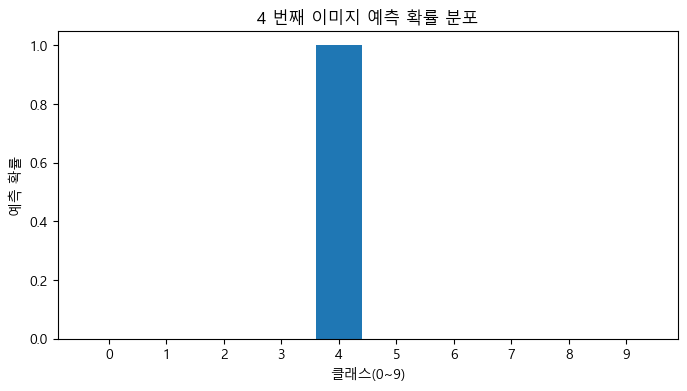

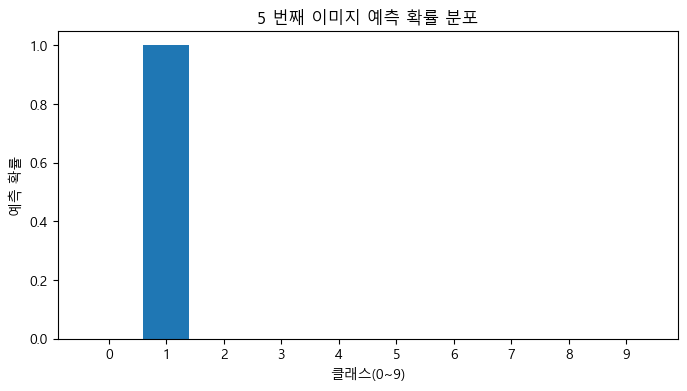

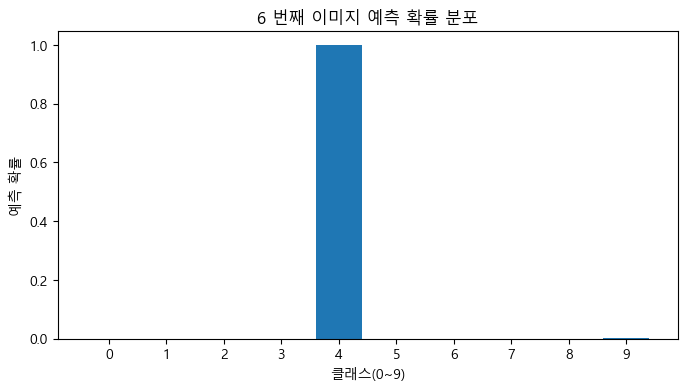

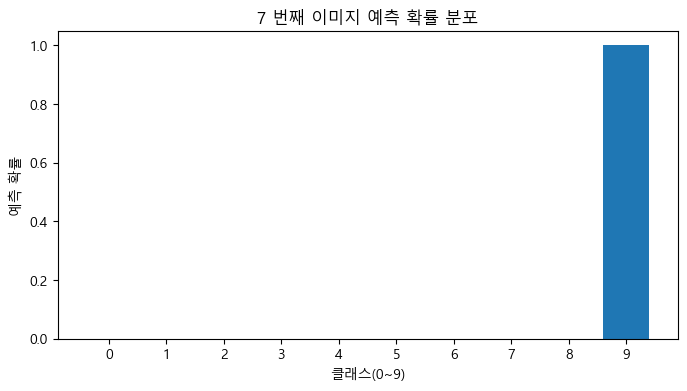

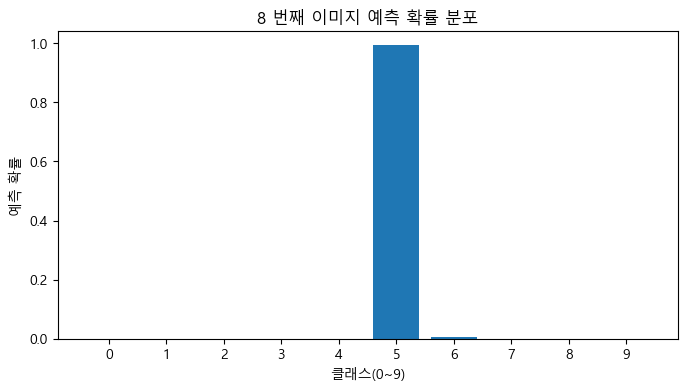

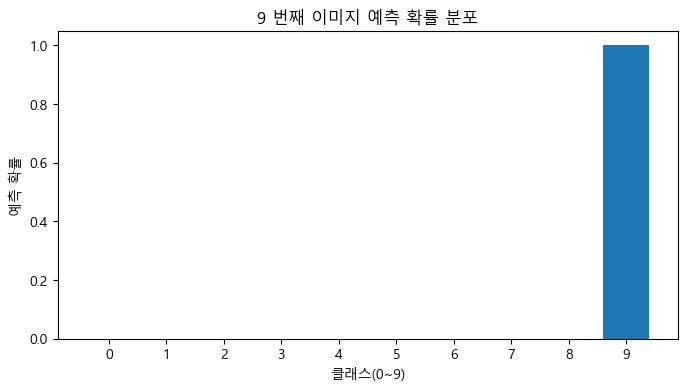

In [35]:
for i in range(10):
    plt.figure(figsize=(8,4))
    plt.bar(range(10), predictions[i])
    plt.xticks(range(10))
    plt.xlabel("클래스(0~9)")
    plt.ylabel("예측 확률")
    plt.title("{} 번째 이미지 예측 확률 분포".format(i))
plt.show()